# Missing Values Analysis & Cleaning

## 1. Load Dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('simfin_dataset.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]} ...")
df.head(3)


Shape: (18088, 91)
Columns: ['Ticker', 'Report Date', 'Fiscal Year', 'Revenue', 'Cost of Revenue', 'Gross Profit', 'Operating Expenses', 'Selling, General & Administrative', 'Research & Development', 'Depreciation & Amortization'] ...


,Ticker,Report Date,Fiscal Year,Revenue,Cost of Revenue,Gross Profit,Operating Expenses,"Selling, General & Administrative",Research & Development,Depreciation & Amortization,...,Net Change in Investments,Company Name,IndustryId,Sector,Industry,Market,Main Currency,Perform,FiscalYear,Class
0,A,2020-10-31,2020.0,5.339000e+09,-2.502000e+09,2.837000e+09,-1.991000e+09,-1.496000e+09,-495000000.0,NaN,...,NaN,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,0.427021,2020,1.0
1,A,2021-10-31,2021.0,6.319000e+09,-2.912000e+09,3.407000e+09,-2.060000e+09,-1.619000e+09,-441000000.0,NaN,...,NaN,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.212426,2021,0.0
2,A,2022-10-31,2022.0,6.848000e+09,-3.126000e+09,3.722000e+09,-2.104000e+09,-1.637000e+09,-467000000.0,NaN,...,NaN,AGILENT TECHNOLOGIES INC,106001.0,Healthcare,Medical Diagnostics & Research,us,USD,-0.140251,2022,-1.0


## 2. Missing Values Overview

In [11]:
# Exclude non-feature columns from analysis
META = {'Ticker', 'Report Date', 'Sector', 'Industry', 'Perform', 'Class',
        'FiscalYear', 'fin_type', 'Company Name', 'IndustryId',
        'Market', 'Main Currency', 'Fiscal Year'}
feature_cols = [c for c in df.columns
                if c not in META and pd.api.types.is_numeric_dtype(df[c])]

miss_pct  = df[feature_cols].isnull().mean().sort_values(ascending=False)
miss_count = df[feature_cols].isnull().sum().sort_values(ascending=False)

print(f"Total feature columns:     {len(feature_cols)}")
print(f"Columns fully complete:    {(miss_pct == 0).sum()}")
print(f"Columns with any missing:  {(miss_pct > 0).sum()}")
print(f"Columns > 70% missing:     {(miss_pct > 0.70).sum()}")
print(f"Columns > 50% missing:     {(miss_pct > 0.50).sum()}")
print()
print(df[feature_cols].isnull().sum().sum(), "total missing cells out of",
      df[feature_cols].size, f"({df[feature_cols].isnull().mean().mean()*100:.1f}% overall)")


Total feature columns:     76
Columns fully complete:    0
Columns with any missing:  76
Columns > 70% missing:     24
Columns > 50% missing:     30

568903 total missing cells out of 1374688 (41.4% overall)


In [12]:
# Full table sorted by missing rate
miss_df = pd.DataFrame({
    'Missing Count': miss_count,
    'Missing %':     (miss_pct * 100).round(1)
})
with pd.option_context('display.max_rows', 100):
    print(miss_df[miss_df['Missing Count'] > 0].to_string())


                                                 Missing Count  Missing %
Policyholders Equity                                     18088      100.0
Income (Loss) from Affiliates, Net of Taxes              18070       99.9
Change in Inventories                                    17992       99.5
Change in Accounts Payable                               17983       99.4
Change in Accounts Receivable                            17965       99.3
Change in Other                                          17920       99.1
Effect of Foreign Exchange Rates                         17907       99.0
Preferred Equity                                         17842       98.6
Total Claims & Losses                                    17838       98.6
Insurance Reserves                                       17808       98.5
Net Change in Investments                                17805       98.4
Total Investments                                        17790       98.4
Interbank Assets                      

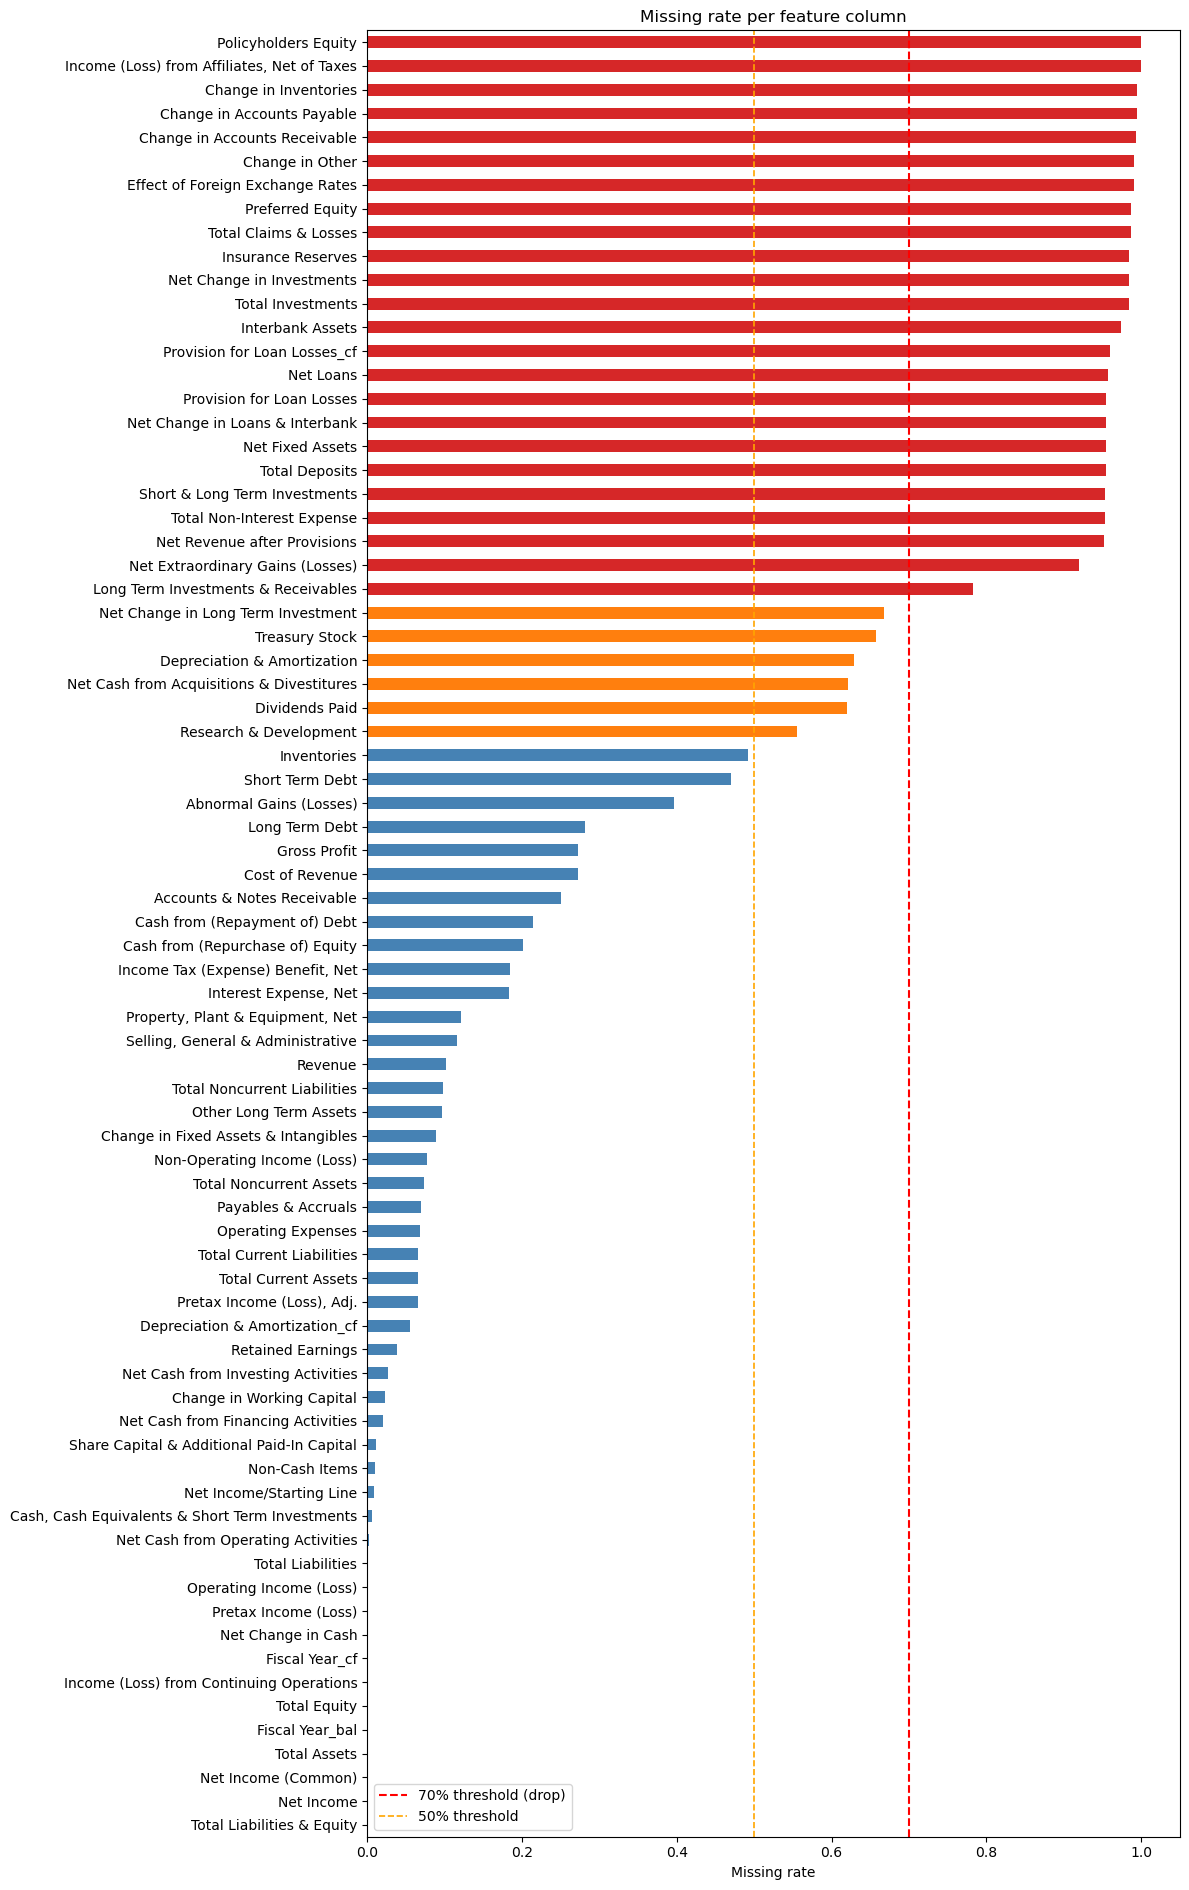

Red bars = will be dropped (>70% missing)


In [13]:
# Bar chart — all columns with any missing values
to_plot = miss_pct[miss_pct > 0].sort_values()
fig, ax = plt.subplots(figsize=(12, max(4, len(to_plot) * 0.25)))
colors = ['#d62728' if v > 0.70 else '#ff7f0e' if v > 0.50 else 'steelblue'
          for v in to_plot]
to_plot.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.70, color='red',    linestyle='--', linewidth=1.5, label='70% threshold (drop)')
ax.axvline(0.50, color='orange', linestyle='--', linewidth=1.2, label='50% threshold')
ax.set_xlabel('Missing rate')
ax.set_title('Missing rate per feature column')
ax.legend()
plt.tight_layout()
plt.show()
print("Red bars = will be dropped (>70% missing)")


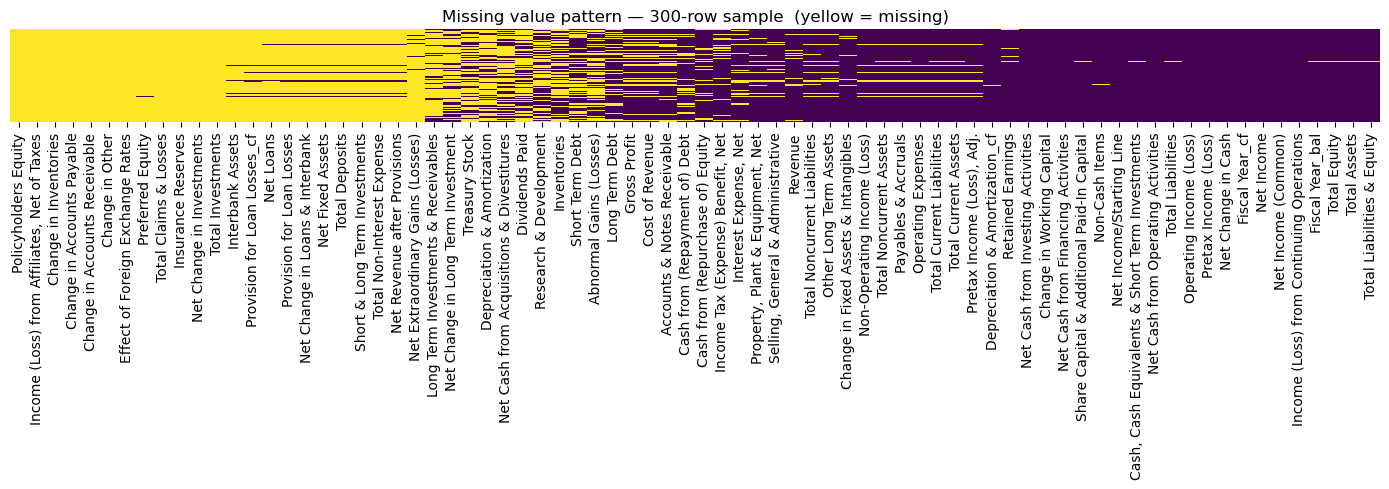

In [14]:
# Heatmap — missing pattern on a 300-row sample
sample_cols = miss_pct[miss_pct > 0].index.tolist()
if sample_cols:
    sample = df[sample_cols].sample(min(300, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.heatmap(sample.isnull(), cbar=False, cmap='viridis',
                yticklabels=False, ax=ax)
    ax.set_title('Missing value pattern — 300-row sample  (yellow = missing)')
    plt.tight_layout()
    plt.show()


## 3. Drop Features with > 50% Missing Values

In [15]:
THRESHOLD = 0.50
cols_to_drop = miss_pct[miss_pct > THRESHOLD].index.tolist()
cols_to_keep = miss_pct[miss_pct <= THRESHOLD].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with > {THRESHOLD*100:.0f}% missing:")
for c in cols_to_drop:
    print(f"  {c:<60}  {miss_pct[c]*100:.1f}%")

df_clean = df.drop(columns=cols_to_drop)
print(f"\nShape before: {df.shape}")
print(f"Shape after:  {df_clean.shape}  ({df.shape[1] - df_clean.shape[1]} columns removed)")


Dropping 30 columns with > 50% missing:
  Policyholders Equity                                          100.0%
  Income (Loss) from Affiliates, Net of Taxes                   99.9%
  Change in Inventories                                         99.5%
  Change in Accounts Payable                                    99.4%
  Change in Accounts Receivable                                 99.3%
  Change in Other                                               99.1%
  Effect of Foreign Exchange Rates                              99.0%
  Preferred Equity                                              98.6%
  Total Claims & Losses                                         98.6%
  Insurance Reserves                                            98.5%
  Net Change in Investments                                     98.4%
  Total Investments                                             98.4%
  Interbank Assets                                              97.4%
  Provision for Loan Losses_cf                   

## 4. Impute Remaining Missing Values

In [16]:
remaining_features = [c for c in cols_to_keep if c in df_clean.columns]

# Check how many values still need imputation
still_missing = df_clean[remaining_features].isnull().sum()
still_missing = still_missing[still_missing > 0].sort_values(ascending=False)
print(f"Columns still needing imputation: {len(still_missing)} / {len(remaining_features)}")
print(f"Total cells to impute:            {still_missing.sum():,}")
print()
print("Missing count per column (before imputation):")
print(still_missing.head(20).to_string())


Columns still needing imputation: 46 / 46
Total cells to impute:            82,209

Missing count per column (before imputation):
Inventories                             8900
Short Term Debt                         8504
Abnormal Gains (Losses)                 7161
Long Term Debt                          5099
Gross Profit                            4924
Cost of Revenue                         4923
Accounts & Notes Receivable             4539
Cash from (Repayment of) Debt           3867
Cash from (Repurchase of) Equity        3641
Income Tax (Expense) Benefit, Net       3349
Interest Expense, Net                   3310
Property, Plant & Equipment, Net        2185
Selling, General & Administrative       2111
Revenue                                 1836
Total Noncurrent Liabilities            1773
Other Long Term Assets                  1756
Change in Fixed Assets & Intangibles    1602
Non-Operating Income (Loss)             1398
Total Noncurrent Assets                 1332
Payables & Accr

In [17]:
# Strategy: sector-median imputation (financially meaningful)
# Falls back to global median for rows without a sector label

df_imputed = df_clean.copy()

for col in still_missing.index:
    if 'Sector' in df_imputed.columns:
        # Fill with sector median
        sector_median = df_imputed.groupby('Sector')[col].transform('median')
        df_imputed[col] = df_imputed[col].fillna(sector_median)

    # Fill any remaining NaNs (missing sector or sector has all-NaN) with global median
    global_median = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(global_median)

# Verify
still_after = df_imputed[remaining_features].isnull().sum().sum()
print(f"Missing cells before imputation: {still_missing.sum():,}")
print(f"Missing cells after imputation:  {still_after:,}")

if still_after == 0:
    print("\nAll missing values successfully imputed.")
else:
    remaining = df_imputed[remaining_features].isnull().sum()
    print("\nColumns still incomplete (entire sector group was NaN):")
    print(remaining[remaining > 0].to_string())


Missing cells before imputation: 82,209
Missing cells after imputation:  0

All missing values successfully imputed.


## 5. Final Dataset Overview

In [18]:
print("Shape after column drop + imputation:", df_imputed.shape)
print(f"Unique companies: {df_imputed['Ticker'].nunique():,}")
print()
print("Class distribution:")
print(df_imputed['Class'].value_counts().sort_index().to_string())
print()
print("Sector breakdown:")
print(df_imputed['Sector'].value_counts().to_string())
print()
print("Sample rows:")
df_imputed[remaining_features[:6] + ['Sector','Perform','Class']].head(5)


Shape after column drop + imputation: (18088, 61)
Unique companies: 4,786

Class distribution:
Class
-1.0    4531
 0.0    4534
 1.0    4536

Sector breakdown:
Sector
Healthcare            4194
Technology            2840
Consumer Cyclical     2425
Financial Services    2375
Industrials           2241
Real Estate            920
Energy                 852
Basic Materials        805
Consumer Defensive     760
Utilities              279
Business Services      237
Other                   25

Sample rows:


,Inventories,Short Term Debt,Abnormal Gains (Losses),Long Term Debt,Gross Profit,Cost of Revenue,Sector,Perform,Class
0,7.200000e+08,75000000.0,-2795185.0,2.284000e+09,2.837000e+09,-2.502000e+09,Healthcare,0.427021,1.0
1,8.300000e+08,5941427.0,-2795185.0,2.729000e+09,3.407000e+09,-2.912000e+09,Healthcare,-0.212426,0.0
2,1.038000e+09,36000000.0,-2795185.0,2.733000e+09,3.722000e+09,-3.126000e+09,Healthcare,-0.140251,-1.0
3,1.031000e+09,5941427.0,-2795185.0,2.735000e+09,3.465000e+09,-3.368000e+09,Healthcare,0.219616,1.0
4,9.720000e+08,45000000.0,-2795185.0,3.345000e+09,3.535000e+09,-2.975000e+09,Healthcare,NaN,NaN


## 6. Save Cleaned & Imputed Dataset

In [19]:
df_imputed.to_csv('simfin_cleaned_imputed.csv', index=False)
print(f"Saved simfin_cleaned_imputed.csv")
print(f"Shape: {df_imputed.shape}")
print(f"Missing values remaining: {df_imputed[remaining_features].isnull().sum().sum()}")


Saved simfin_cleaned_imputed.csv
Shape: (18088, 61)
Missing values remaining: 0


In [21]:
df_imputed.columns

Index(['Ticker', 'Report Date', 'Fiscal Year', 'Revenue', 'Cost of Revenue',
       'Gross Profit', 'Operating Expenses',
       'Selling, General & Administrative', 'Operating Income (Loss)',
       'Non-Operating Income (Loss)', 'Interest Expense, Net',
       'Pretax Income (Loss), Adj.', 'Abnormal Gains (Losses)',
       'Pretax Income (Loss)', 'Income Tax (Expense) Benefit, Net',
       'Income (Loss) from Continuing Operations', 'Net Income',
       'Net Income (Common)', 'fin_type', 'Fiscal Year_bal',
       'Cash, Cash Equivalents & Short Term Investments',
       'Accounts & Notes Receivable', 'Inventories', 'Total Current Assets',
       'Property, Plant & Equipment, Net', 'Other Long Term Assets',
       'Total Noncurrent Assets', 'Total Assets', 'Payables & Accruals',
       'Short Term Debt', 'Total Current Liabilities', 'Long Term Debt',
       'Total Noncurrent Liabilities', 'Total Liabilities',
       'Share Capital & Additional Paid-In Capital', 'Retained Earnings',
  